# Financial Risk Analysis with Python

## Task 1: Data Cleaning and Formatting

In [212]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, zscore
from datetime import datetime

### Import libraries: Sets up required libraries for data cleaning and analysis.

In [213]:
df1 = pd.read_csv("goldman_sachs.csv")

### 1.1 and 1.2 Remove/treat any special characters or non-numeric entries from financial fields

In [214]:
cols = ['TransactionAmount', 'AccountBalance', 'RiskScore']

for col in cols:
    df1[col] = (
        df1[col]
        .astype(str)
        .str.replace(r'[^0-9.-]', '', regex=True)
        .astype(float)
    )

### Clean numeric fields: Converts transaction amount, balance, and risk score into valid numeric values.

### 1.3 Validate and format date columns.

In [216]:
df['TransactionDate'] = pd.to_datetime(
    df['TransactionDate'],
    errors='coerce'
)

### Date validation: Converts transaction dates into a proper datetime format.

### 1.4 Ensure account types and transaction categories are standardized

In [217]:
df['AccountType'] = df['AccountType'].str.lower().str.strip()
df['TransactionType'] = df['TransactionType'].str.lower().str.strip()

### Standardize text fields: Ensures uniform formatting of account and transaction types.

In [218]:
df1.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,33,CUST6549,ACC12334,Credit,Withdrawal,Savings Account,Firm C,Central,Manager 1,21-10-2023,87480.05448,74008.43310,0.729101,319,200
1,177,CUST2942,ACC52650,Credit,Withdrawal,Home Loan,Firm A,East,Manager 3,20-06-2023,20315.74505,22715.83590,0.472424,692,47
2,178,CUST6776,ACC45101,Current,Deposit,Personal Loan,Firm C,South,Manager 3,02-01-2023,10484.57165,42706.09210,0.648784,543,109
3,173,CUST2539,ACC88252,Current,Withdrawal,Mutual Fund,Firm A,Central,Manager 2,25-07-2023,45122.27373,114176.56870,0.734832,430,103
4,67,CUST2626,ACC21878,Savings,Withdrawal,Home Loan,Firm C,Central,Manager 4,25-07-2023,42360.79878,17863.02644,0.289304,468,234


In [215]:
df = pd.read_csv("Cleaned_Data.csv")

## Task 2: Descriptive Transactional Analysis 

### 2.1 Calculate monthly and yearly summaries of total credits, debits, and net transaction volume.

In [219]:
df['Month'] = df['TransactionDate'].dt.to_period('M')
df['Year'] = df['TransactionDate'].dt.year

### Create Month & Year: Extracts month and year from transaction dates for time-based aggregation.

In [220]:
summary = df.pivot_table(
    values='TransactionAmount',
    index='Month',
    columns='TransactionType',
    aggfunc='sum'
)
summary['Net'] = summary.get('credit',0) - summary.get('debit',0)

### Pivot summary table: Aggregates total transaction amounts by month and transaction type.
### Net calculation: Computes net transaction volume as total credits minus total debits per month.

In [221]:
summary.head()

TransactionType,deposit,payment,transfer,withdrawal,Net
Month,,,,,
2023-01,738270.104450,767715.190774,503614.959706,1.047046e+06,0
2023-02,648261.004850,354836.661930,286550.139330,7.924666e+05,0
2023-03,604002.422140,865951.649660,545314.714480,6.165271e+05,0
2023-04,439321.687687,590121.520674,301770.393640,4.464024e+05,0
2023-05,425589.871840,906411.880360,731136.024250,5.661674e+05,0


### 2.2 Plot trends in total credits vs. debits over time.

In [222]:
df['Txn_Category'] = df['TransactionType'].map({
    'deposit': 'credit',
    'transfer': 'debit',
    'payment': 'debit',
    'withdrawal': 'debit'
})

### Transaction categorization: Classifies transactions into credit and debit categories.

In [223]:
monthly_summary = df.pivot_table(
    values='TransactionAmount',
    index='Month',
    columns='Txn_Category',
    aggfunc='sum'
)

### Monthly aggregation: Computes monthly totals of credits and debits.

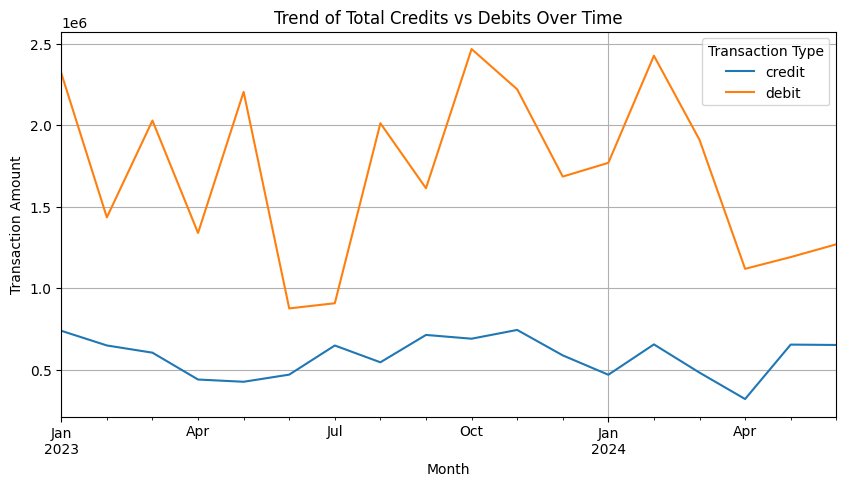

In [224]:
monthly_summary[['credit', 'debit']].plot(figsize=(10,5))

plt.title("Trend of Total Credits vs Debits Over Time")
plt.xlabel("Month")
plt.ylabel("Transaction Amount")
plt.legend(title="Transaction Type")
plt.grid(True)
plt.show()

### Trend visualization: Plots monthly trends of total credits versus debits over time.

### 2.3 Identify top and bottom performing accounts based on net inflow.

In [278]:
account_flow = df.groupby('AccountID')['TransactionAmount'].sum()

top_accounts = account_flow.sort_values(ascending=False).head(10)
bottom_accounts = account_flow.sort_values().head(10)

### Net inflow calculation: Computes net transaction inflow for each account by summing all transactions.

In [279]:
print(top_accounts)

AccountID
ACC46655    728037.402705
ACC33287    591591.095890
ACC16241    539612.142850
ACC53466    494957.158800
ACC29396    482720.015550
ACC83269    468734.595390
ACC57700    465047.926414
ACC60432    462957.849880
ACC29356    435573.496188
ACC13357    432527.808260
Name: TransactionAmount, dtype: float64


### Top accounts identification: Identifies the top 10 accounts with the highest net inflow.

In [280]:
print(bottom_accounts)

AccountID
ACC46953   -24811.428950
ACC11062     4014.264900
ACC43771    14033.502560
ACC87602    14944.062400
ACC26956    15603.452120
ACC21429    20442.761880
ACC78089    26828.979199
ACC62809    34979.062450
ACC29007    35207.179489
ACC29646    36055.574280
Name: TransactionAmount, dtype: float64


### Bottom accounts identification: Identifies the bottom 10 accounts with the lowest net inflow.

### 2.4 Identify and flag accounts as dormant or inactive if there is a gap of two months or more between consecutive transactions.

In [226]:
df = df.sort_values(['AccountID','TransactionDate'])

df['Gap'] = df.groupby('AccountID')['TransactionDate'].diff().dt.days

df['Inactive_Flag'] = df['Gap'].apply(lambda x: "Inactive" if x >= 60 else "Active")

In [227]:
df[['AccountID','Inactive_Flag']].head()

,AccountID,Inactive_Flag
0,ACC10117,Active
1,ACC10117,Active
2,ACC10117,Inactive
3,ACC10117,Inactive
4,ACC10996,Active


### This part identifies inactive accounts by checking if there is a gap of two months or more between their transactions

## Task 3: Customer Profile Building 

### 3.1 Group accounts by activity levels: High, Medium, Low based on transaction frequency on your analysis and rubrics. Do not forget to mention the rubric in the headings.

In [228]:
txn_freq = (
    df
    .groupby('AccountID')
    .size()
    .reset_index(name='TxnCount')   
)
def activity_level(count):
    if count > 20:
        return 'High'
    elif count >= 10:
        return 'Medium'
    else:
        return 'Low'

transction_frequency['ActivityLevel'] = (
    transction_frequency['TxnCount'].apply(activity_level)
)
activity_balance = transction_frequency.merge(
    df.groupby('AccountID')['AccountBalance']
        .mean()
        .reset_index(),
    on='AccountID'
)

txn_freq['ActivityLevel'] = txn_freq['TxnCount'].apply(activity_level)

In [229]:
txn_freq.head()

,AccountID,TxnCount,ActivityLevel
0,ACC10117,4,Low
1,ACC10996,5,Low
2,ACC11062,2,Low
3,ACC11188,5,Low
4,ACC11285,3,Low


### This step groups customer accounts into high, medium, and low activity levels based on how frequently they perform transactions

### 3.2 Segment customers by average balance and transaction volume

In [230]:
customer_profile = df.groupby('AccountID').agg(
    AvgBalance=('AccountBalance', 'mean'),
    TotalTxnVolume=('TransactionAmount', 'sum')
).reset_index()


### Calculates average balance and total transaction volume for each account.

In [231]:
balance_median = customer_profile['AvgBalance'].median()
volume_median = customer_profile['TotalTxnVolume'].median()

### It Determines median balance and transaction volume as segmentation thresholds.

In [232]:
def segment_customer(row):
    if row['AvgBalance'] > balance_median and row['TotalTxnVolume'] > volume_median:
        return 'High Balance – High Volume'
    elif row['AvgBalance'] > balance_median and row['TotalTxnVolume'] <= volume_median:
        return 'High Balance – Low Volume'
    elif row['AvgBalance'] <= balance_median and row['TotalTxnVolume'] > volume_median:
        return 'Low Balance – High Volume'
    else:
        return 'Low Balance – Low Volume'

customer_profile['CustomerSegment'] = customer_profile.apply(segment_customer, axis=1)

### Defines customer segments based on high/low balance and transaction volume.

In [233]:
segment_summary = customer_profile['CustomerSegment'].value_counts()

In [234]:
customer_profile.head()

,AccountID,AvgBalance,TotalTxnVolume,CustomerSegment
0,ACC10117,70107.007957,199480.967430,Low Balance – Low Volume
1,ACC10996,43568.008084,250739.550950,Low Balance – High Volume
2,ACC11062,38137.132610,4014.264900,Low Balance – Low Volume
3,ACC11188,69652.151044,257576.603590,Low Balance – High Volume
4,ACC11285,97401.348560,96729.609841,High Balance – Low Volume


### This step segments customers by balance and transaction volume so we can understand customer value and target high-value and high-activity customers more effectively.

### 3.3.1 High-net inflow accounts

In [235]:
# Separate credit and debit amounts
df['CreditAmount'] = df.apply(
    lambda x: x['TransactionAmount'] if x['Txn_Category'] == 'credit' else 0,
    axis=1
)

df['DebitAmount'] = df.apply(
    lambda x: x['TransactionAmount'] if x['Txn_Category'] == 'debit' else 0,
    axis=1
)

# Net inflow per account
net_inflow = df.groupby('AccountID').agg(
    TotalCredit=('CreditAmount', 'sum'),
    TotalDebit=('DebitAmount', 'sum')
)

net_inflow['NetInflow'] = net_inflow['TotalCredit'] - net_inflow['TotalDebit']

# High‑net inflow accounts
high_net_inflow_accounts = net_inflow[net_inflow['NetInflow'] > 0]


In [236]:
high_net_inflow_accounts.head()

,TotalCredit,TotalDebit,NetInflow
AccountID,,,
ACC10117,142170.20378,57310.76365,84859.44013
ACC15359,122856.48300,120413.19788,2443.28512
ACC18140,45680.91092,38542.74767,7138.16325
ACC19178,64100.78213,0.00000,64100.78213
ACC21264,79561.48165,58077.64916,21483.83249


### This step identifies high net inflow accounts to find financially strong customers who bring more money into the bank than they withdraw

### 3.3.2 High-frequency low-balance accounts

In [237]:
# Transaction frequency per account
txn_freq = df.groupby('AccountID').size()

# Average balance per account
avg_balance = df.groupby('AccountID')['AccountBalance'].mean()

# Combine
hf_lb = pd.concat([txn_freq, avg_balance], axis=1)
hf_lb.columns = ['TxnCount', 'AvgBalance']

# Thresholds
freq_median = hf_lb['TxnCount'].median()
balance_median = hf_lb['AvgBalance'].median()

# High‑frequency, low‑balance accounts
high_freq_low_balance_accounts = hf_lb[
    (hf_lb['TxnCount'] > freq_median) &
    (hf_lb['AvgBalance'] < balance_median)
]


In [238]:
high_freq_low_balance_accounts.head()

,TxnCount,AvgBalance
AccountID,,
ACC10996,5,43568.008084
ACC11188,5,69652.151044
ACC13357,6,69179.806513
ACC18177,5,63505.219474
ACC23736,7,60801.533102


### This step identifies customers who transact frequently but maintain low balances, helping the bank target potential upselling or financial risk customers

### 3.3.3 Accounts with negative or near-zero balances

In [239]:
negative_near_zero_accounts = avg_balance[
    avg_balance <= 1000
]

### Low balance filtering: Identifies accounts with negative or near-zero average balances.

In [240]:
negative_near_zero_accounts.head()

AccountID
ACC19178   -1541.176812
Name: AccountBalance, dtype: float64

### This step identifies accounts with negative or very low balances so the bank can detect financially stressed customers and take preventive actions.

## Task 4: Financial Risk Identification 

### 4.1 Track accounts with frequent large withdrawals or overdrafts

In [241]:
df['TxnNature'] = df['TransactionType'].map({
    'deposit': 'Credit',
    'withdrawal': 'Debit',
    'payment': 'Debit',
    'transfer': 'Debit'
})

In [242]:
# Filter large withdrawals
large_withdrawals = df[
    (df['TransactionType'] == 'withdrawal') &
    (df['TransactionAmount'] > 50000)
]

# Count per account
large_withdrawal_count = large_withdrawals.groupby('AccountID').size().reset_index(
    name='LargeWithdrawalCount'
)

# View result
large_withdrawal_count.head()

,AccountID,LargeWithdrawalCount
0,ACC10996,1
1,ACC11188,1
2,ACC12334,1
3,ACC15228,2
4,ACC15359,1


### This step identifies accounts with frequent large withdrawals to detect potential financial risk or abnormal customer behavior

In [243]:
# Filter overdraft transactions
overdrafts = df[df['AccountBalance'] < 0]

# Count per account
overdraft_count = overdrafts.groupby('AccountID').size().reset_index(
    name='OverdraftCount'
)

# View result
overdraft_count.head()

,AccountID,OverdraftCount
0,ACC16241,1
1,ACC19178,1
2,ACC23736,1
3,ACC26973,1
4,ACC28154,1


### This step tracks overdraft accounts to identify customers under financial stress and assess credit risk

### 4.2 Calculate balance volatility using standard deviation or coefficient of variation.

In [244]:
# Standard Deviation of Account Balance
balance_stats = df.groupby('AccountID')['AccountBalance'].agg(
    MeanBalance='mean',
    StdBalance='std'
).reset_index()

In [245]:
# Coefficient of Variation (CV)
balance_stats['CV'] = (
    balance_stats['StdBalance'] / balance_stats['MeanBalance']
)

#CV > 0.5 → High volatility → Risky account
#CV ≤ 0.5 → Stable account

In [246]:
balance_stats.head()

,AccountID,MeanBalance,StdBalance,CV
0,ACC10117,70107.007957,25886.972758,0.369249
1,ACC10996,43568.008084,9434.002316,0.216535
2,ACC11062,38137.132610,3208.737888,0.084137
3,ACC11188,69652.151044,35494.660810,0.509599
4,ACC11285,97401.348560,55922.732441,0.574147


### This step measures balance volatility to identify unstable or risky accounts based on frequent balance fluctuations.

### 4.3 Use IQR or z-score methods to detect anomalies

In [247]:
Q1 = df['TransactionAmount'].quantile(0.15)
Q3 = df['TransactionAmount'].quantile(0.85)

IQR = Q3 - Q1

In [248]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


In [249]:
iqr_anomalies = df[
    (df['TransactionAmount'] < lower_bound) |
    (df['TransactionAmount'] > upper_bound)
]

In [250]:
iqr_anomaly_count = iqr_anomalies.groupby('AccountID').size().reset_index(
    name='AnomalyCount'
)

In [251]:
iqr_anomaly_count.sum()

AccountID       0
AnomalyCount    0
dtype: object

### Here, I check for unusual transaction amounts using the IQR method, and the result shows that all transactions fall within a normal range

### 4.4 Highlight customers with irregular or suspicious transaction behavior

In [252]:
suspicious_df = large_withdrawal_count.merge(
    overdraft_count, on='AccountID', how='outer'
).merge(
    iqr_anomaly_count, on='AccountID', how='outer'
)

suspicious_df.fillna(0, inplace=True)


In [253]:
suspicious_df['SuspiciousFlag'] = suspicious_df.apply(
    lambda x: 'Suspicious' if (
        x['LargeWithdrawalCount'] > 0 or
        x['OverdraftCount'] > 0 or
        x['AnomalyCount'] > 0
    ) else 'Normal',
    axis=1
)

In [254]:
suspicious_customers = suspicious_df[
    suspicious_df['SuspiciousFlag'] == 'Suspicious'
]

In [255]:
suspicious_customers.head()

,AccountID,LargeWithdrawalCount,OverdraftCount,AnomalyCount,SuspiciousFlag
0,ACC10996,1.0,0.0,0.0,Suspicious
1,ACC11188,1.0,0.0,0.0,Suspicious
2,ACC12334,1.0,0.0,0.0,Suspicious
3,ACC15228,2.0,0.0,0.0,Suspicious
4,ACC15359,1.0,0.0,0.0,Suspicious


### Here, I combine all risk factors like large withdrawals, overdrafts, and anomalies to finally flag customers with suspicious transaction behavior.

## Task 5: Visualisation

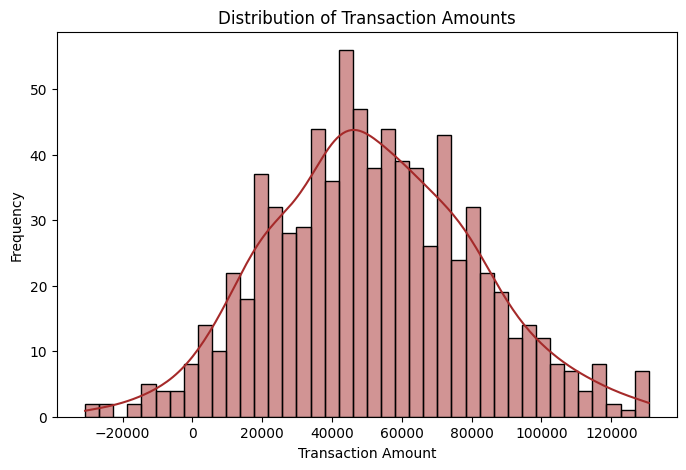

In [256]:
plt.figure(figsize=(8,5))
sns.histplot(df['TransactionAmount'], bins=40, kde=True, color="brown")
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()

### This visualization helps understand overall transaction behavior, identify normal transaction ranges, and visually detect extreme values that may indicate financial risk or anomalies.

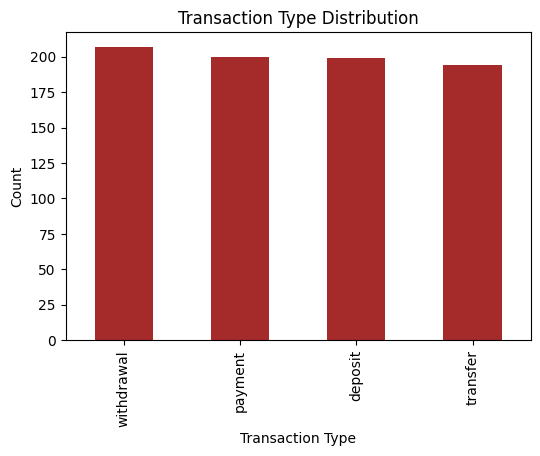

In [257]:
txn_type_counts = df['TransactionType'].value_counts()

plt.figure(figsize=(6,4))
txn_type_counts.plot(kind='bar',color="brown")
plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

### This chart shows how frequently each transaction type occurs, helping analyze customer transaction behavior and cash flow patterns

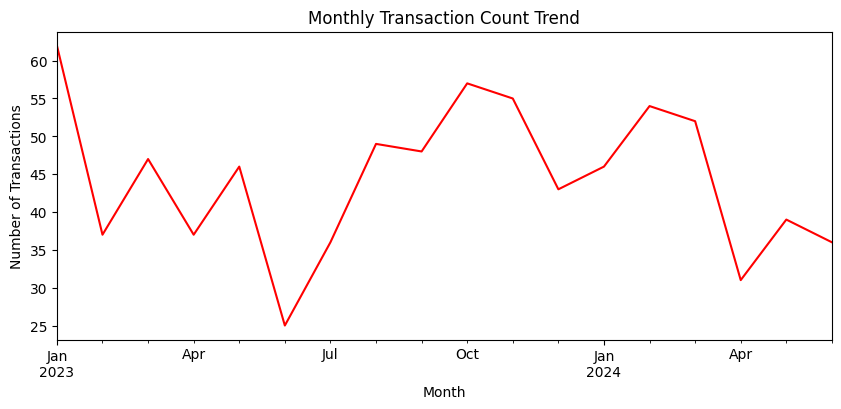

In [258]:
monthly_txn_count = df.groupby('Month').size()

plt.figure(figsize=(10,4))
monthly_txn_count.plot(color="red")
plt.title("Monthly Transaction Count Trend")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.show()

### This chart shows how the number of transactions changes month by month, helping identify peak and low activity periods

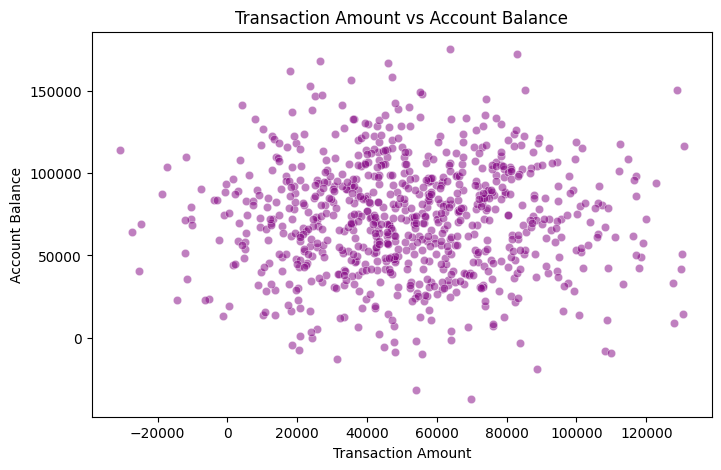

In [259]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df['TransactionAmount'],
    y=df['AccountBalance'],
    alpha=0.5, color="purple"
)
plt.title("Transaction Amount vs Account Balance")
plt.xlabel("Transaction Amount")
plt.ylabel("Account Balance")
plt.show()

### This plot compares transaction amounts with account balances to understand customer spending and balance behavior

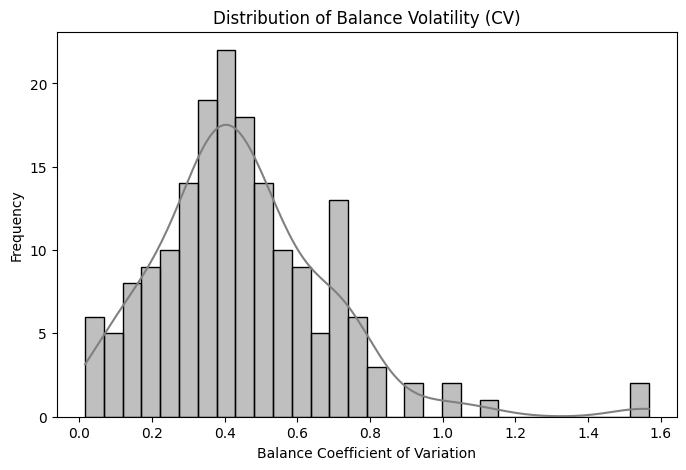

In [260]:
plt.figure(figsize=(8,5))
sns.histplot(balance_stats['CV'], bins=30, kde=True, color="grey")
plt.title("Distribution of Balance Volatility (CV)")
plt.xlabel("Balance Coefficient of Variation")
plt.ylabel("Frequency")
plt.show()

### This chart shows how stable or unstable customer balances are, helping identify accounts with high financial risk.

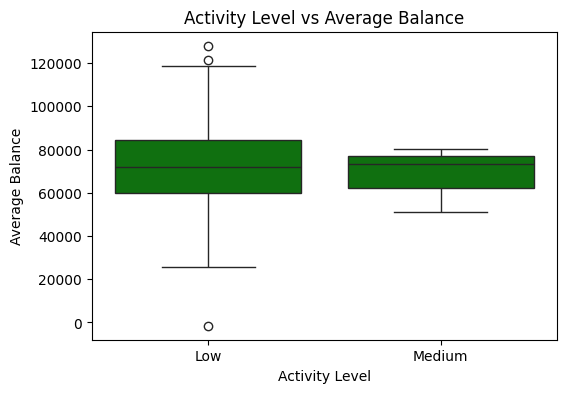

In [281]:
transction_frequency = (
    df
    .groupby('AccountID')
    .size()
    .reset_index(name='TxnCount')  
)
def activity_level(count):
    if count > 20:
        return 'High'
    elif count >= 10:
        return 'Medium'
    else:
        return 'Low'

transction_frequency['ActivityLevel'] = (
    transction_frequency['TxnCount'].apply(activity_level)
)
activity_balance = transction_frequency.merge(
    df.groupby('AccountID')['AccountBalance']
        .mean()
        .reset_index(),
    on='AccountID'
)
plt.figure(figsize=(6,4))
sns.boxplot(
    x=activity_balance['ActivityLevel'],
    y=activity_balance['AccountBalance'],
    color= "green"
)
plt.title("Activity Level vs Average Balance")
plt.xlabel("Activity Level")
plt.ylabel("Average Balance")
plt.show()

### This analysis helps understand the relationship between transaction frequency and account balance, supporting customer segmentation and value assessment.

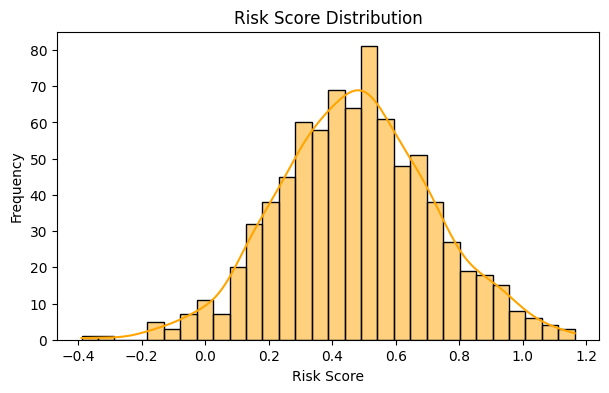

In [262]:
plt.figure(figsize=(7,4))
sns.histplot(df['RiskScore'], bins=30, kde=True,color="orange")
plt.title("Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Frequency")
plt.show()

### This histogram shows how customer risk scores are distributed across accounts, indicating the spread of low, medium, and high risk levels.

# Task 6 Hypothesis Testing

### H₀ (Null Hypothesis): There is no significant difference in average account balance between high-volume and low-volume transaction accounts.

### H₁ (Alternative Hypothesis): High-volume transaction accounts have a significantly higher average balance than low-volume transaction accounts.

In [263]:
# Count transactions per account
txn_count = df.groupby('AccountID').size().reset_index(name='TxnCount')
print(txn_count)

    AccountID  TxnCount
0    ACC10117         4
1    ACC10996         5
2    ACC11062         2
3    ACC11188         5
4    ACC11285         3
..        ...       ...
189  ACC97225         3
190  ACC97411         2
191  ACC99117         3
192  ACC99409         4
193  ACC99549         4

[194 rows x 2 columns]


In [264]:
# Find median transaction count
median_txn = txn_count['TxnCount'].median()
print(median_txn)

4.0


In [265]:
# Label accounts
txn_count['VolumeGroup'] = txn_count['TxnCount'].apply(
    lambda x: 'High Volume' if x > median_txn else 'Low Volume'
)

In [266]:
avg_balance = df.groupby('AccountID')['AccountBalance'].mean().reset_index(
    name='AvgBalance'
)


In [267]:
avg_balance.head()

,AccountID,AvgBalance
0,ACC10117,70107.007957
1,ACC10996,43568.008084
2,ACC11062,38137.132610
3,ACC11188,69652.151044
4,ACC11285,97401.348560


In [268]:
analysis_df = txn_count.merge(avg_balance, on='AccountID')
analysis_df.head()

,AccountID,TxnCount,VolumeGroup,AvgBalance
0,ACC10117,4,Low Volume,70107.007957
1,ACC10996,5,High Volume,43568.008084
2,ACC11062,2,Low Volume,38137.132610
3,ACC11188,5,High Volume,69652.151044
4,ACC11285,3,Low Volume,97401.348560


In [269]:
high_volume_bal = analysis_df[
    analysis_df['VolumeGroup'] == 'High Volume'
]['AvgBalance']

low_volume_bal = analysis_df[
    analysis_df['VolumeGroup'] == 'Low Volume'
]['AvgBalance']

In [274]:
high_volume_bal.head()

1    43568.008084
3    69652.151044
7    78082.517883
8    69179.806513
9    95389.614144
Name: AvgBalance, dtype: float64

In [275]:
low_volume_bal.head()

0    70107.007957
2    38137.132610
4    97401.348560
5    84852.733695
6    83837.145895
Name: AvgBalance, dtype: float64

In [276]:
t_stat, p_value = ttest_ind(
    high_volume_bal,
    low_volume_bal,
    equal_var=False
)

In [271]:
print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 0.31506769364079873
P-value: 0.753053414974672


In [277]:
alpha = 0.05  

if p_value < alpha:
    print("Reject the Null Hypothesis (H0)")
else:
    print("Fail to Reject the Null Hypothesis (H0)")

Fail to Reject the Null Hypothesis (H0)


### The hypothesis test shows that high transaction volume does not necessarily mean a higher average account balance

### There is no statistically significant difference in average account balances between high-volume and low-volume transaction accounts.